# `Intro`

## `Title - Bank Account Fraud Classification model`

Description: Supervised machine-learning pipeline aimed to distinguish fraudulent online bank account applications from legitimate applications.

Dataset: Synthetic, anonymized dataset sourced from [Kaggle.com](https://www.kaggle.com/datasets/sgpjesus/bank-account-fraud-dataset-neurips-2022)
1,000,000 instances | 32 features

## `Models`

Logistic Regression : linear model for binary classification

--

Decision Tree : non-linearity (large dataset)

--

RandomForest : provides contrast to DecisionTree's functionality, overcoming the limitations imposed by DecisionTree overfitting while highlighting the strengths/limitations of *bagging*

--

XGBoost : highlights the strengths/limitations of *boosting* 

In [ ]:
import subprocess

# eda
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# models
from sklearn.linear_model import LogisticRegression # logistic regression classifier
from sklearn.tree import DecisionTreeClassifier # decisiontree
from sklearn.ensemble import RandomForestClassifier # randomforest / assess effect of bagging
from xgboost import XGBClassifier # xgboost classifier / assess effect of boosting

# preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

# training
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_predict

# evaluation
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_auc_score
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay 

# persistence/preservation of computational resources 
import joblib

# `EDA/Prep`

## `Load Dataset`


In [2]:
df = pd.read_csv("Base.csv")

## `Dataset Dimensions`

In [3]:
print(f'Displaying first ten instances: \n\n {df.head(10)} \n \n This dataset has {df.shape[0]} applications, each of which comprising {df.shape[1]} features.')

Displaying first ten instances: 

    fraud_bool  income  name_email_similarity  prev_address_months_count  \
0           0     0.3               0.986506                         -1   
1           0     0.8               0.617426                         -1   
2           0     0.8               0.996707                          9   
3           0     0.6               0.475100                         11   
4           0     0.9               0.842307                         -1   
5           0     0.6               0.294840                         -1   
6           0     0.2               0.773085                         22   
7           0     0.8               0.153880                         -1   
8           0     0.3               0.523655                         21   
9           0     0.8               0.834475                         -1   

   current_address_months_count  customer_age  days_since_request  \
0                            25            40            0.006735   
1

## `Class Imbalance`

In [4]:
print(df['fraud_bool'].value_counts(normalize=True))

fraud_bool
0    0.988971
1    0.011029
Name: proportion, dtype: float64


## `Null Values`

### `Null val counts`

In [5]:
#missing_val_count = df.isnull().sum()

#print(missing_val_count)

Conventional null value assessment (i.e., df.isnull().sum()) suggests this dataset contains no null values; however, this method introduces a slight inaccuracy within the context of this dataset. Certain columns (i.e., 'prev_address_months_count','current_address_months_count', and 'bank_months_count') present null values as -1. 

While null values typically raise eyebrows in a Data Science context--necessitating dropping or imputation--their presence, or lack thereof, is actually valuable. With respect to the columns with null values, 'prev_address_months_count' might indicate lack of information disclosure or even fraudulence. Fraudulent applicants are not likely to disclose their locations, whether past or present, and they will likely not have a previous account with the banking institution. Simply put, intelligent fraudsters are not likely to disclose their location or target an institution to which they might be tied.

In [6]:
def null_val_assess(dataframe):
    '''Assesses dataframe for null values, 
    providing count and percentage of null values'''

    null_val_assessment = []

    # list of columns with null_vals as -1
    target_cols = ['prev_address_months_count', 
                   'current_address_months_count', 
                   'bank_months_count']
    
    filtered_df = dataframe[target_cols] # filter dataframe using passed list of columns

    null_val_mask = (filtered_df == -1) # boolean mask for any vals of -1 in filtered dataframe 

    count = null_val_mask.sum() # counts of null val
    percent = (null_val_mask.mean() * 100) # reduced computation with respect to size of data

    null_val_assessment.append({
        'Null val count' : count,
        'Null val percent' : percent
    })

    null_val_df = pd.DataFrame(null_val_assessment)
    display(null_val_df)

    return target_cols

In [7]:
null_val_cols = null_val_assess(df)

,Null val count,Null val percent
0,prev_address_months_count 712920 current...,prev_address_months_count 71.2920 curren...


### `Null Val Imputation`

In [8]:
def null_val_handling(dataframe, target_cols):
    '''Applies median imputation to handle null vals'''

    for col in target_cols:

        # using boolean masking to create additional column of null vals for each col in target_cols (display purposes)
        # replacing booleans with ints streamlines model interpretation
        dataframe[f'{col}_null_vals'] = (dataframe[col] == -1).astype(int)

        # calculates median for each col in target col
        # using median to overcome positive-skewing by negative values (long tails to right)
        col_median = dataframe.loc[dataframe[col] != -1, col].median()

        # imputes null vals using col_median
        # modifies entire column by finding and filling nulls
        dataframe[col] = dataframe[col].replace(-1, np.nan).fillna(col_median)

    # inspect successful imputation
    display(dataframe.head())

    return dataframe

In [9]:
df_clean = null_val_handling(df, null_val_cols)

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,...,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month,prev_address_months_count_null_vals,current_address_months_count_null_vals,bank_months_count_null_vals
0,0,0.3,0.986506,34.0,25.0,40,0.006735,102.453711,AA,1059,...,INTERNET,16.224843,linux,1,1,0,0,1,0,0
1,0,0.8,0.617426,34.0,89.0,20,0.010095,-0.849551,AD,1658,...,INTERNET,3.363854,other,1,1,0,0,1,0,0
2,0,0.8,0.996707,9.0,14.0,40,0.012316,-1.490386,AB,1095,...,INTERNET,22.730559,windows,0,1,0,0,0,0,0
3,0,0.6,0.475100,11.0,14.0,30,0.006991,-1.863101,AB,3483,...,INTERNET,15.215816,linux,1,1,0,0,0,0,0
4,0,0.9,0.842307,34.0,29.0,40,5.742626,47.152498,AA,2339,...,INTERNET,3.743048,other,0,1,0,0,1,0,0


## `Feature Categorization`

In [10]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 35 columns):
 #   Column                                  Non-Null Count    Dtype  
---  ------                                  --------------    -----  
 0   fraud_bool                              1000000 non-null  int64  
 1   income                                  1000000 non-null  float64
 2   name_email_similarity                   1000000 non-null  float64
 3   prev_address_months_count               1000000 non-null  float64
 4   current_address_months_count            1000000 non-null  float64
 5   customer_age                            1000000 non-null  int64  
 6   days_since_request                      1000000 non-null  float64
 7   intended_balcon_amount                  1000000 non-null  float64
 8   payment_type                            1000000 non-null  object 
 9   zip_count_4w                            1000000 non-null  int64  
 10  velocity_6h                    

In [11]:
def classify_features(dataframe):
    '''Segments input features to either a categorical or numerical list'''

    print(f'Classifying features...')

    categorical_alphas = ['payment_type', 'employment_status', 'housing_status',
                          'source', 'device_os']
    
    numerical_feats = []

    features_list = [] # display

    for feature in dataframe.columns:
        if feature == 'fraud_bool':
            features_list.append({
                'Feature' : feature,
                'Type' : 'numerical | Target Variable'
            })

        elif feature in categorical_alphas:
            features_list.append({
                'Feature' : feature,
                'Type' : 'categorical | input variable'
            })

        else:
            numerical_feats.append(feature)
            features_list.append({
                'Feature' : feature,
                'Type' : 'numerical | input variable'
            })

    features_df = pd.DataFrame(features_list)

    print(f'Features classified.')
    display(features_df)

    return categorical_alphas, numerical_feats

In [12]:
categorical_features, numerical_features = classify_features(df_clean)

Classifying features...
Features classified.


,Feature,Type
0,fraud_bool,numerical | Target Variable
1,income,numerical | input variable
2,name_email_similarity,numerical | input variable
3,prev_address_months_count,numerical | input variable
4,current_address_months_count,numerical | input variable
5,customer_age,numerical | input variable
6,days_since_request,numerical | input variable
7,intended_balcon_amount,numerical | input variable
8,payment_type,categorical | input variable
9,zip_count_4w,numerical | input variable


## `Correlated Features`

In [13]:
df_clean[numerical_features].corr()

,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,zip_count_4w,velocity_6h,velocity_24h,...,proposed_credit_limit,foreign_request,session_length_in_minutes,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month,prev_address_months_count_null_vals,current_address_months_count_null_vals,bank_months_count_null_vals
income,1.000000,-0.038519,0.016638,-0.036871,0.125822,-0.015877,0.059046,-0.080581,-0.096431,-0.101269,...,0.108868,0.011452,-0.055430,-0.043584,-0.009992,NaN,0.116479,-0.012673,0.004519,-0.042948
name_email_similarity,-0.038519,1.000000,-0.006050,0.050101,-0.048902,-0.007736,0.029040,0.025114,0.024881,0.035221,...,0.073159,-0.015224,0.005998,0.014342,-0.017804,NaN,-0.042949,0.036779,-0.007360,0.010781
prev_address_months_count,0.016638,-0.006050,1.000000,-0.125395,-0.018202,0.045318,0.000252,-0.009332,-0.003633,-0.000661,...,-0.006778,0.010327,0.025382,0.018403,0.010062,NaN,0.005713,-0.334422,0.017872,0.044762
current_address_months_count,-0.036871,0.050101,-0.125395,1.000000,0.142375,-0.057420,0.057030,0.046854,0.027078,0.018578,...,0.130314,-0.012320,-0.033256,-0.050480,-0.000738,NaN,-0.024295,0.465373,-0.025047,-0.053832
customer_age,0.125822,-0.048902,-0.018202,0.142375,1.000000,-0.035999,-0.013000,-0.014176,-0.022063,-0.010030,...,0.148857,-0.001606,0.025049,-0.024272,0.025709,NaN,0.005694,0.150883,-0.018671,-0.018265
days_since_request,-0.015877,-0.007736,0.045318,-0.057420,-0.035999,1.000000,0.019782,0.000249,0.027968,0.023869,...,-0.068670,0.001066,0.049613,0.000337,0.009025,NaN,-0.017938,-0.113822,0.013050,0.091301
intended_balcon_amount,0.059046,0.029040,0.000252,0.057030,-0.013000,0.019782,1.000000,0.002251,0.042849,0.064080,...,0.057860,0.007933,0.022811,-0.020689,-0.019910,NaN,-0.043070,0.026800,-0.016922,-0.258354
zip_count_4w,-0.080581,0.025114,-0.009332,0.046854,-0.014176,0.000249,0.002251,1.000000,0.142372,0.201186,...,-0.011651,0.017212,0.039687,0.022283,0.020550,NaN,-0.287203,0.061142,-0.012975,-0.026840
velocity_6h,-0.096431,0.024881,-0.003633,0.027078,-0.022063,0.027968,0.042849,0.142372,1.000000,0.464003,...,-0.025005,-0.000450,0.054491,0.002797,0.030030,NaN,-0.409148,-0.004777,-0.012028,-0.028263
velocity_24h,-0.101269,0.035221,-0.000661,0.018578,-0.010030,0.023869,0.064080,0.201186,0.464003,1.000000,...,0.017725,0.015419,0.066875,-0.000567,0.034981,NaN,-0.549919,-0.026601,-0.005239,-0.040537


'Device_fraud_count' reflects a history of fraud associated with the specified device (i.e., the device from which applications are submitted). Devices flagged with fraudulent history are assessed as 1; devices without are assessed as 0 and labeled as missing values in the above correlation analysis dataframe. With respect to the dataset class imbalance and high frequency of zeroes in the 'device_fraud_count' column, this column will be dropped prior to re-calculating values in the analysis below. 

In [14]:
correlated_feats = [f for f in numerical_features if f != 'device_fraud_count']

df_clean[correlated_feats].corr()

,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,zip_count_4w,velocity_6h,velocity_24h,...,has_other_cards,proposed_credit_limit,foreign_request,session_length_in_minutes,keep_alive_session,device_distinct_emails_8w,month,prev_address_months_count_null_vals,current_address_months_count_null_vals,bank_months_count_null_vals
income,1.000000,-0.038519,0.016638,-0.036871,0.125822,-0.015877,0.059046,-0.080581,-0.096431,-0.101269,...,0.086861,0.108868,0.011452,-0.055430,-0.043584,-0.009992,0.116479,-0.012673,0.004519,-0.042948
name_email_similarity,-0.038519,1.000000,-0.006050,0.050101,-0.048902,-0.007736,0.029040,0.025114,0.024881,0.035221,...,0.011021,0.073159,-0.015224,0.005998,0.014342,-0.017804,-0.042949,0.036779,-0.007360,0.010781
prev_address_months_count,0.016638,-0.006050,1.000000,-0.125395,-0.018202,0.045318,0.000252,-0.009332,-0.003633,-0.000661,...,-0.021808,-0.006778,0.010327,0.025382,0.018403,0.010062,0.005713,-0.334422,0.017872,0.044762
current_address_months_count,-0.036871,0.050101,-0.125395,1.000000,0.142375,-0.057420,0.057030,0.046854,0.027078,0.018578,...,0.060186,0.130314,-0.012320,-0.033256,-0.050480,-0.000738,-0.024295,0.465373,-0.025047,-0.053832
customer_age,0.125822,-0.048902,-0.018202,0.142375,1.000000,-0.035999,-0.013000,-0.014176,-0.022063,-0.010030,...,0.108743,0.148857,-0.001606,0.025049,-0.024272,0.025709,0.005694,0.150883,-0.018671,-0.018265
days_since_request,-0.015877,-0.007736,0.045318,-0.057420,-0.035999,1.000000,0.019782,0.000249,0.027968,0.023869,...,-0.048861,-0.068670,0.001066,0.049613,0.000337,0.009025,-0.017938,-0.113822,0.013050,0.091301
intended_balcon_amount,0.059046,0.029040,0.000252,0.057030,-0.013000,0.019782,1.000000,0.002251,0.042849,0.064080,...,0.096676,0.057860,0.007933,0.022811,-0.020689,-0.019910,-0.043070,0.026800,-0.016922,-0.258354
zip_count_4w,-0.080581,0.025114,-0.009332,0.046854,-0.014176,0.000249,0.002251,1.000000,0.142372,0.201186,...,-0.015015,-0.011651,0.017212,0.039687,0.022283,0.020550,-0.287203,0.061142,-0.012975,-0.026840
velocity_6h,-0.096431,0.024881,-0.003633,0.027078,-0.022063,0.027968,0.042849,0.142372,1.000000,0.464003,...,-0.007049,-0.025005,-0.000450,0.054491,0.002797,0.030030,-0.409148,-0.004777,-0.012028,-0.028263
velocity_24h,-0.101269,0.035221,-0.000661,0.018578,-0.010030,0.023869,0.064080,0.201186,0.464003,1.000000,...,-0.030688,0.017725,0.015419,0.066875,-0.000567,0.034981,-0.549919,-0.026601,-0.005239,-0.040537


### `Correlated Features Breakdown`

The correlation matrix above indicates that '*velocity_4w*', '*velocity_24h*', and '*velocity_6h*' are all strongly correlated with each other, which aligns logically. Given that these applications are being submitted online--with high frequency submissions being indicators of automated bot behavior--fraudsters are likely to push more applications, exploiting probability at scale. Additionally, the aforementioned features show strong, negative correlations to '*month*' ~(-0.85, -0.55, -0.41, respectively). This implies a *temporal artifact*. Intelligent criminals, as individuals, do not frequently target the same institution; however, they are known to form cabals and develop a set of modus operandi--targeting institutions with similar standard-operating procedures and security protocols. Once a fraudster successfully achieves their goal, they may proceed to the next target; however, if the fraudster is initially unsuccessful, they may begin to submit fewer applications within a certain window so as to not arouse suspicion. This may lead them to change devices or seek the support of other fraudsters to optimize efficacy. Within the context of this study, the data suggest that velocity (i.e., speed and frequency of online application submissions) decreases as the months progress. 

In [15]:
# list concatenation to assess correlation between inputs and target variable

target_var = correlated_feats + ['fraud_bool']

df_clean[target_var].corr()

,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,zip_count_4w,velocity_6h,velocity_24h,...,proposed_credit_limit,foreign_request,session_length_in_minutes,keep_alive_session,device_distinct_emails_8w,month,prev_address_months_count_null_vals,current_address_months_count_null_vals,bank_months_count_null_vals,fraud_bool
income,1.000000,-0.038519,0.016638,-0.036871,0.125822,-0.015877,0.059046,-0.080581,-0.096431,-0.101269,...,0.108868,0.011452,-0.055430,-0.043584,-0.009992,0.116479,-0.012673,0.004519,-0.042948,0.045079
name_email_similarity,-0.038519,1.000000,-0.006050,0.050101,-0.048902,-0.007736,0.029040,0.025114,0.024881,0.035221,...,0.073159,-0.015224,0.005998,0.014342,-0.017804,-0.042949,0.036779,-0.007360,0.010781,-0.036720
prev_address_months_count,0.016638,-0.006050,1.000000,-0.125395,-0.018202,0.045318,0.000252,-0.009332,-0.003633,-0.000661,...,-0.006778,0.010327,0.025382,0.018403,0.010062,0.005713,-0.334422,0.017872,0.044762,-0.010663
current_address_months_count,-0.036871,0.050101,-0.125395,1.000000,0.142375,-0.057420,0.057030,0.046854,0.027078,0.018578,...,0.130314,-0.012320,-0.033256,-0.050480,-0.000738,-0.024295,0.465373,-0.025047,-0.053832,0.033569
customer_age,0.125822,-0.048902,-0.018202,0.142375,1.000000,-0.035999,-0.013000,-0.014176,-0.022063,-0.010030,...,0.148857,-0.001606,0.025049,-0.024272,0.025709,0.005694,0.150883,-0.018671,-0.018265,0.062959
days_since_request,-0.015877,-0.007736,0.045318,-0.057420,-0.035999,1.000000,0.019782,0.000249,0.027968,0.023869,...,-0.068670,0.001066,0.049613,0.000337,0.009025,-0.017938,-0.113822,0.013050,0.091301,0.000567
intended_balcon_amount,0.059046,0.029040,0.000252,0.057030,-0.013000,0.019782,1.000000,0.002251,0.042849,0.064080,...,0.057860,0.007933,0.022811,-0.020689,-0.019910,-0.043070,0.026800,-0.016922,-0.258354,-0.024524
zip_count_4w,-0.080581,0.025114,-0.009332,0.046854,-0.014176,0.000249,0.002251,1.000000,0.142372,0.201186,...,-0.011651,0.017212,0.039687,0.022283,0.020550,-0.287203,0.061142,-0.012975,-0.026840,0.005212
velocity_6h,-0.096431,0.024881,-0.003633,0.027078,-0.022063,0.027968,0.042849,0.142372,1.000000,0.464003,...,-0.025005,-0.000450,0.054491,0.002797,0.030030,-0.409148,-0.004777,-0.012028,-0.028263,-0.016892
velocity_24h,-0.101269,0.035221,-0.000661,0.018578,-0.010030,0.023869,0.064080,0.201186,0.464003,1.000000,...,0.017725,0.015419,0.066875,-0.000567,0.034981,-0.549919,-0.026601,-0.005239,-0.040537,-0.011183


Assessment of each input feature (excluding 'device_fraud_count') against the target variable reveals weak correlation values across the board, with some of these weak values being negative. In fact, the highest correlation value is ~0.07. 

This clearly conveys the truth that fraudulence is multi-faceted, deeming fraudulent occurrences to be unpredictable based on assessment of an isolated input feature.

## `Visualization`

In [16]:
print(f'For a more detailed visualization of the relationships between each signal indicator,' 
      ' click the local address directly below.\n*Note that bank_fraud_signal_analysis_app.py must be downloaded.* \n')
subprocess.Popen(['python', 'bank_fraud_signal_analysis_app.py'])
print(f'Signal Analysis Dashboard at http://127.0.0.1:8050')

For a more detailed visualization of the relationships between each signal indicator, click the local address directly below.
*Note that bank_fraud_signal_analysis_app.py must be downloaded.* 

Signal Analysis Dashboard at http://127.0.0.1:8050


## `Data Partitioning`

In [17]:
def partition_data(dataframe, **kwargs):
    '''Partitions data while reserving 20% for test data,
    and setting a random_state for reproducibility'''

    test_size = kwargs.get('test_size', 0.20)
    random_state = kwargs.get('random_state', 415)
    target_variable = kwargs.get('target_variable', 'fraud_bool')

    # drop target variable to prevent data leakage
    X = dataframe.drop(columns=target_variable)

    # assign target variable as y
    y = dataframe[target_variable]

    # partition dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y, 
        test_size=test_size,
        random_state=random_state,
        stratify=y # prevents class imbalance drift between training and test data partitions,
                   # ensuring even split
    )

    return X_train, X_test, y_train, y_test

In [18]:
X_train, X_test, y_train, y_test = partition_data(df_clean, test_size=0.20, random_state=415, target_variable='fraud_bool')

## `Encoding Categorical Features`

In [19]:
def feature_encoding(training_features, testing_features, categorical_inputs, numerical_inputs, **kwargs):
    '''Encodes features based on specified encoding method (i.e., OneHot or Ordinal)'''

    sparse_output = kwargs.get('sparse_output', False)
    drop_strategy = kwargs.get('drop_strategy', 'first')
    encoding_method = kwargs.get('encoding_method', 'ohe')
    categories = kwargs.get('categories')

    # one-hot encoding (assumes unordered ranking between features) | selected for this project
    if encoding_method == 'ohe':
        ohe_transformer = ColumnTransformer(transformers=[
            (encoding_method, OneHotEncoder(sparse_output=sparse_output, drop=drop_strategy), categorical_inputs),
            ('scaler', StandardScaler(),                                                        numerical_inputs)
        ])

        X_train_one_hot_enc = ohe_transformer.fit_transform(training_features)
        X_test_one_hot_enc = ohe_transformer.transform(testing_features)

        print(f'X_train_oheenc shape: {X_train_one_hot_enc.shape}')
        print(f'X_test_oheenc shape: {X_test_one_hot_enc.shape}')

        return ohe_transformer, X_train_one_hot_enc, X_test_one_hot_enc
    
    # ordinal encoding (assumes hierarchical ranking between features)
    elif encoding_method == 'ordinal':
        ordinal_transformer = ColumnTransformer(transformers=[
            (encoding_method, OrdinalEncoder(categories=categories), categorical_inputs),
            ('scaler', StandardScaler(),                              numerical_inputs)
        ])

        X_train_ordinal_enc = ordinal_transformer.fit_transform(training_features)
        X_test_ordinal_enc = ordinal_transformer.transform(testing_features)

        print(f'X_train_ordenc shape: {X_train_ordinal_enc.shape}')
        print(f'X_test_ordenc shape: {X_test_ordinal_enc.shape}')

        return ordinal_transformer, X_train_ordinal_enc, X_test_ordinal_enc

In [20]:
ohe_transformer, X_train_one_hot_enc, X_test_ohe_enc = feature_encoding(X_train, X_test, categorical_features, numerical_features, encoding_method='ohe', sparse_output=False, drop_strategy='first')

X_train_oheenc shape: (800000, 50)
X_test_oheenc shape: (200000, 50)


# `Training Models`

## `Instantiating Classifiers`

In [21]:
list_of_algos = [
    (LogisticRegression, {'max_iter': 100000, 'class_weight': 'balanced'}),
    (DecisionTreeClassifier, {'random_state':415, 'class_weight': 'balanced'}),
    (RandomForestClassifier, {'random_state':415, 'class_weight': 'balanced'}), 
    (XGBClassifier, {
        'max_depth':6, 'learning_rate': 0.3, 'n_estimators':100, 'scale_pos_weight':89, 
        'eval_metric': 'auc', 'random_state' : 415, 'tree_method' : 'hist'
    })
]

model_list = [model(**params) for model, params in list_of_algos]

log_regressor_default, decision_tree_default, random_forest_default, xgboost_default = model_list

## `Calculating the Label Predictions and Probability Predictions from each classifier`

In [22]:
def calc_preds_and_probs(list_of_models, **kwargs):
    '''Calculates the label predictions and probability predictions from each classifier'''

    model_preds = []

    X = kwargs.get('X')
    y = kwargs.get('y')
    cv = kwargs.get('cv', 5)
    method = kwargs.get('method', 'predict_proba')

    for model in list_of_models:

        # calculation of probability predictions
        # returns one row per applicant (col_index_0 : probability of legit | col_index_1 : probability of fraud)
        probs = cross_val_predict(model, X, y, cv=cv, method=method)
        
        # calculation of label predictions
        # extracts fraud probability (col index 1) for each applicant as boolean and casts as int (0:legit or 1:fraud)
        preds = (probs[:,1] >= 0.5).astype(int) 
    
        # adding to list
        model_preds.append(preds)
        model_preds.append(probs)

    return model_preds

In [ ]:
log_regressor_default_preds, log_regressor_default_probs, \ 
decision_tree_default_preds, decision_tree_default_probs, \ 
random_forest_default_preds, random_forest_default_probs, \ 
xgboost_default_preds, xgboost_default_probs = calc_preds_and_probs(model_list, X=X_train_one_hot_enc, y=y_train, cv=5, method='predict_proba')

## `Save CV Results for Default Models`

In [ ]:
cv_results = {
    'lr': (log_regressor_default_preds, log_regressor_default_probs),
    'dt': (decision_tree_default_preds, decision_tree_default_probs),
    'rf': (random_forest_default_preds, random_forest_default_probs),
    'xgb': (xgboost_default_preds, xgboost_default_probs)
}

joblib.dump(cv_results, 'cv_results.pkl')
print('CV results saved')

## `Load CV Results for Default Models`

In [23]:
# load saved CV results - skip calc_preds_and_probs() on subsequent runs
cv_results = joblib.load('cv_results.pkl')

log_regressor_default_preds, log_regressor_default_probs = cv_results['lr']
decision_tree_default_preds, decision_tree_default_probs = cv_results['dt']
random_forest_default_preds, random_forest_default_probs = cv_results['rf']
xgboost_default_preds, xgboost_default_probs = cv_results['xgb']

# `Classifier Evaluation`

## `Calculating and Presenting Evaluation Metrics by Target Class Label per Default Classifier`

In [24]:
def evaluate_model(model_name, y_actual, y_preds, y_probs, **kwargs):
    '''Calculates and presents Confusion matrix, Classification report, ROC-AUC score, and probability plot'''

    # plots kwargs
    bins = kwargs.get('bins', 20)
    edgecolor = kwargs.get('edgecolor', 'black')
    alpha = kwargs.get('alpha', 0.6)

    # confusion matrix
    confus_mtrx = confusion_matrix(y_actual, y_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=confus_mtrx)
    disp.plot()
    plt.title(f'{model_name} -- Confusion Matrix')
    plt.show()

    # classification report
    print(f'{model_name} -- Classification Report')
    print(classification_report(y_actual, y_preds))

    #ROC-AUC
    roc = roc_auc_score(y_actual, y_probs[:, 1]) 
    print(f'{model_name} -- ROC-AUC Score: {roc: .4f}')

    # probability plot
    fig, ax = plt.subplots()
    for label in [0, 1]:
        ax.hist(y_probs[y_actual == label, 1], bins=bins, edgecolor=edgecolor, alpha=alpha, label=f'Legitimate' if label == 0 else 'Fraud')
    ax.set_xlabel('Predicted Probability of Fraud')
    ax.set_ylabel('Count')
    ax.set_title(f'{model_name} -- Predicted Probabilities by Class')
    ax.legend()
    plt.show()

    print(f'-----------------------')

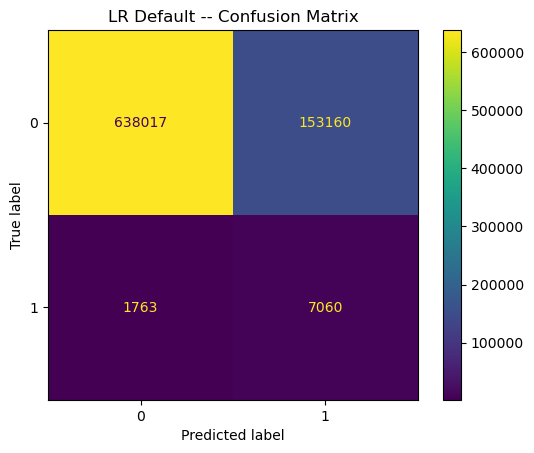

LR Default -- Classification Report
              precision    recall  f1-score   support

           0       1.00      0.81      0.89    791177
           1       0.04      0.80      0.08      8823

    accuracy                           0.81    800000
   macro avg       0.52      0.80      0.49    800000
weighted avg       0.99      0.81      0.88    800000

LR Default -- ROC-AUC Score:  0.8831


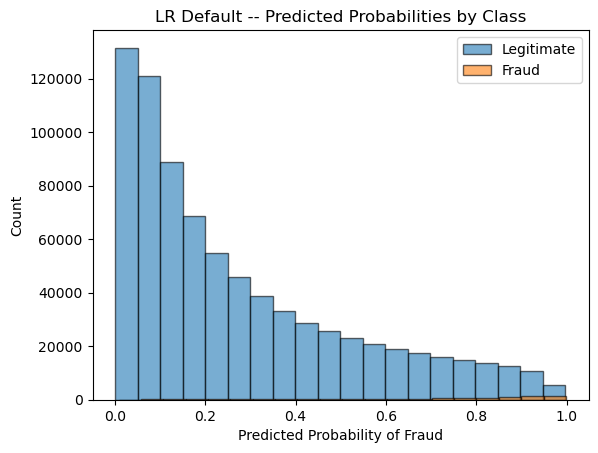

-----------------------


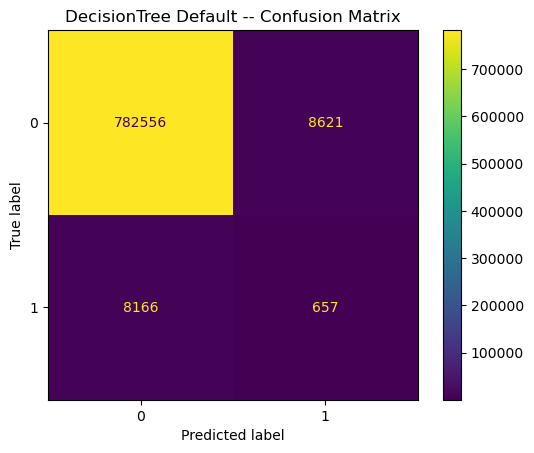

DecisionTree Default -- Classification Report
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    791177
           1       0.07      0.07      0.07      8823

    accuracy                           0.98    800000
   macro avg       0.53      0.53      0.53    800000
weighted avg       0.98      0.98      0.98    800000

DecisionTree Default -- ROC-AUC Score:  0.5318


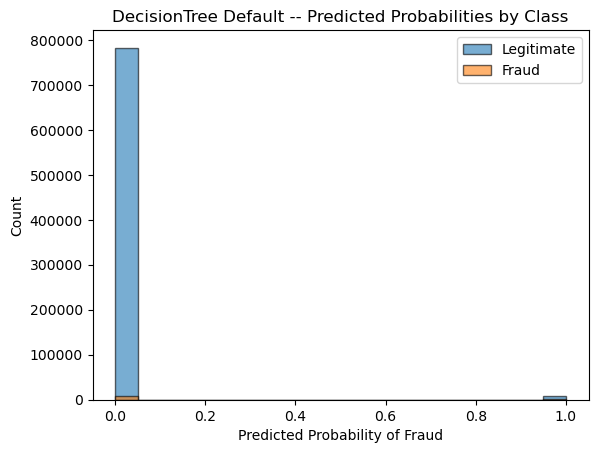

-----------------------


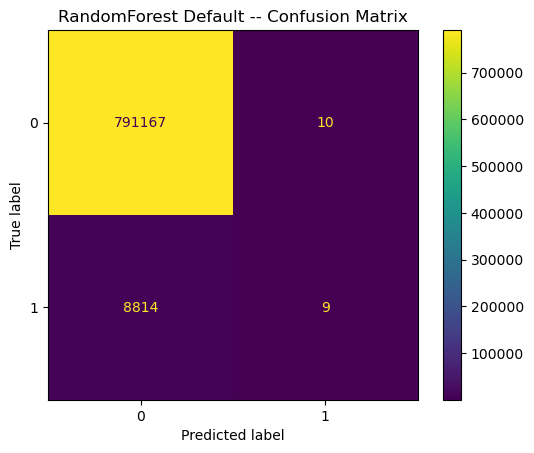

RandomForest Default -- Classification Report
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    791177
           1       0.47      0.00      0.00      8823

    accuracy                           0.99    800000
   macro avg       0.73      0.50      0.50    800000
weighted avg       0.98      0.99      0.98    800000

RandomForest Default -- ROC-AUC Score:  0.8199


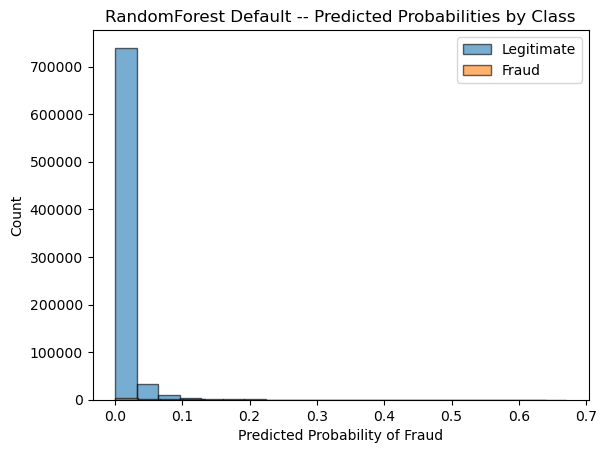

-----------------------


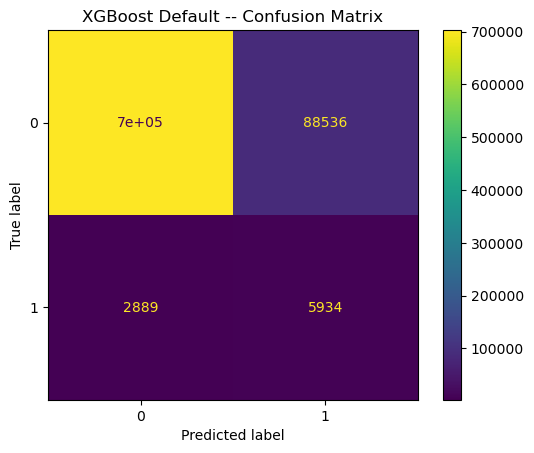

XGBoost Default -- Classification Report
              precision    recall  f1-score   support

           0       1.00      0.89      0.94    791177
           1       0.06      0.67      0.11      8823

    accuracy                           0.89    800000
   macro avg       0.53      0.78      0.53    800000
weighted avg       0.99      0.89      0.93    800000

XGBoost Default -- ROC-AUC Score:  0.8775


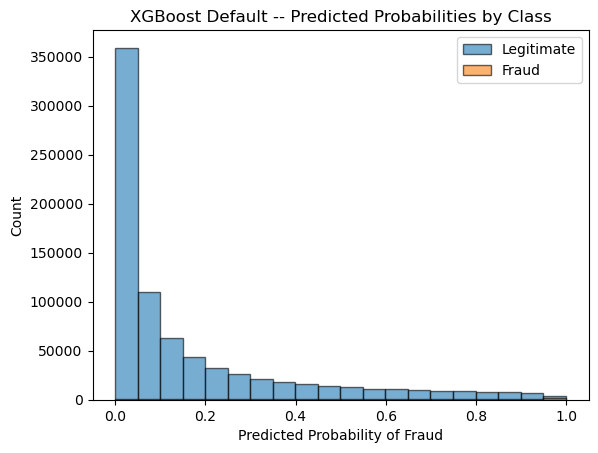

-----------------------


In [25]:
evaluate_model('LR Default', y_train, log_regressor_default_preds, log_regressor_default_probs)
evaluate_model('DecisionTree Default', y_train, decision_tree_default_preds, decision_tree_default_probs)
evaluate_model('RandomForest Default', y_train, random_forest_default_preds, random_forest_default_probs)
evaluate_model('XGBoost Default', y_train, xgboost_default_preds, xgboost_default_probs)

## `Score Breakdown for Default Classifiers`

class_0 = legitimate | class_1 = fraudulent

### `Classification Reports`

Formulas : 
--
TPR (Recall)    = TP / (TP + FN) |
--
Precision = TP / (TP + FP) |
--
Accuracy              = (TP + TN) / (TP + FP + TN + FN) |
---

Metrics :
--

LR = {

precision : {class_0 : 1.00, class_1 : 0.04}, 
recall:     {class_0 : 0.81, class_1 : 0.80}, 
f1-score :  {class_0 : 0.89, class_1 : 0.08}, 
ROC-AUC :   0.8831

} 

--

DT = {

precision: {class_0 : 0.99, class_1 : 0.07},
recall:    {class_0 : 0.99, class_1 : 0.07},
f1-score:  {class_0 : 0.99, class_1 : 0.07},
ROC-AUC:   0.5318

} 

--

RF = {

precision: {class_0 : 0.99, class_1 : 0.47},
recall:    {class_0 : 1.00, class_1 : 0.00},
f1-score:  {class_0 : 0.99, class_1 : 0.00},
ROC-AUC:   0.8199

}

--

XGB = {

precision: {class_0 : 1.00, class_1 : 0.06},
recall:    {class_0 : 0.89, class_1 : 0.67},
f1-score:  {class_0 : 0.94, class_1 : 0.11},
ROC-AUC:    0.8775

} 

---
By definition, adjustment of the *classification threshold* correlates to adjustment of *precision* in the same direction. A lower threshold contributes to lower precision and results in more false positives (i.e., legitimate clients being wrongfully detected as fraudulent). More true positives (i.e., fraudulent applications) are correctly detected by lowering the threshold, thereby reducing the number of false negatives and improving recall. Thus, there exists a paradoxical relationship between *recall* and *precision*. 

With regard to *precision* score, the default logistic regression and XGBoost classifiers showed the highest scores for the *legitimate* classes (1.00 for both). However, the XGB classifier metrics reflected a slightly higher score (0.06) for the *fraudulent* class over the logistic regressor (0.04). Though the default DecisionTree and RandomForest classifiers reported *identical* scores with regard to the *legitimate* classes (0.99), the RandomForest's *class_1* score (0.47) indicates this model outperformed the DecisionTree (0.07).

With regard to *recall*, the RandomForest and DecisionTree showed the highest *class_0* scores, with the former outputting a score of 1.00 against the latter's 0.99. However, the DecisionTree performed better with class_1 detection, showing a score of 0.07 against the RandomForest's 0.00, possibly due to the DecisionTree overfitting and memorizing the data. With a class_0 score of 0.89, XGB outperformed the logistic regressor, 0.81. However, the logistic regressor took the lead in the class_1 recall category, with a score of 0.80 against the XGB's 0.67.

Overall, the DecisionTree and RandomForest output the highest *f1-scores* for class_0. However, the scores become rather nuanced, as the RandomForest classifier matched the DecisionTree's *class_0* score of 0.99, but showed the worst *class_1* score of the four classifiers (0.00). XGB reported an f1-score of 0.94 for class_0 and 0.11 for class_1; whereas, the logistic regressor reported a class_0 f1-score of 0.89 and a class_1 score of 0.08.

Evaluating the *ROC-AUC scores*, which are agnostic to threshold shifts, revealed the *logistic regressor* to have the highest score at 0.8831, followed by *XGB* at 0.8775, then *RandomForest* at 0.8199, and finally *DecisionTree* at 0.5318. Though non-linear models such as the DecisionTree can perform better with datasets of higher cardinality--depending on the encoding method applied--the DecisionTree's woeful ROC-AUC score indicated that it likely overfit to the data and struggled with generalization. The RandomForest classifier is able to capitalize on the DecisionTree's tendency to overfit through simultaneous instantiation of multiple estimators (trees) with each perturbation of the data. Colloquially speaking, this generates an aggregate of trees, with each estimator in the ensemble serving as a subject-matter expert on the data.

In contrast to the RandomForest's simultaneous *bagging* method, lies XGBoost, which applies a *boosting* technique that iteratively instantiates estimators, with each tree designed to reduce the *residual error* of its predecessor. The logistic regressor, on the other hand, is not susceptible to overfitting; instead, this classifier uses maximum likelihood estimation to identify the optimal boundary which separates the data (i.e., classifies the fraudulent applications against the legitimate).

The metrics indicate an imbalance in not only the two classes, but also the threshold's reliability. Thus, a *precision-recall curve* will be constructed to identify an *optimal threshold* before tuning and evaluating the performance of each classifier.

### `Confusion Matrix and Histograms` 

False negatives equate to fraudulent applicants who slip through the cracks. This can become a wasp's nest for banking institutions who do not correctly identify the fraudsters and become proxies for unethical behavior/illegal transactions.

False positives equate to clients who are wrongfully associated with fraudulent behavior. With each false positive, a legitimate client is turned away, contributing to higher attrition rates and pending lawsuits. 

---

Visually, the confusion matrices convey an interesting story. The default *logistic regressor* reported 638,017 true negatives (legitimate applications), 7,060 true positives (fraudulent applications), 1,763 false negatives, and 153,160 false positives. This indicates the logistic regressor was much more aggressive in flagging legitimate applications as fraudulent, while completely missing approximately 20% of the actual fraudsters.

Of the default ensemble classifiers, the *DecisionTree* reported 782,556 truly legitimate applications, with only 657 truly fraudulent applications. Of the misclassified applications, this classifier flagged 8,621 false positives while 8,166 fraudsters went undetected.

The *RandomForest* also struggled. While this ensemble model pushed closer to the underlying class imbalance with respect to classifying the truly legitimate applications (791,167), the model only flagged 9 truly fraudulent applications. In between, 8,814 fraudsters went undetected, while 10 legitimate clients were falsely accused.

*XGBoost's* confusion matrix indicates that the model flagged 702,641 truly legitimate applications against 5,934 truly fraudulent applications. Unfortunately, XGB flagged a significant 88,536 legitimate applications as fraudulent, with a considerable 2,889 fraudulent applications being misclassified as legitimate.

Overall, the histograms of the default logistic regression and XGB classifiers indicate these two models performed the best at recalling the true class imbalance of this dataset, with continuous spreads pertaining to the *predicted probability of fraud*. However, XGBoost exhibited fewer overlaps (i.e., false negatives and false positives), suggesting a minimization of false positives. By contrast, the logistic regressor had more overlap, indicative of greater struggle at truly distinguishing the fraudulent applications from the legitimate applications. The DecisionTree's histogram indicates that applicants had either an extremely low probability of fraud or an absolute probability, whereas the RandomForest's histogram shows a predicted probability of 0.25 or lower for the applicants. With regard to the RandomForest, the majority of applicants varied across the 0.0 to 0.25 range for their predicted probabilities of fraud.

## `Precision - Recall Curve`

In [25]:
model_data = [
    ('Logistic Regressor Default', y_train, log_regressor_default_probs[:, 1]),
    ('DecisionTree Default', y_train, decision_tree_default_probs[:, 1]),
    ('RandomForest Default', y_train, random_forest_default_probs[:, 1]),
    ('XGB Default', y_train, xgboost_default_probs[:, 1])
]

def find_optimal_threshold(model_name, y_actual, y_probs_fraud):
    '''Applies and plots Precision-Recall curve to identify optimal threshold for each classifier'''
    
    # three arrays
    precision, recall, thresholds = precision_recall_curve(y_actual, y_probs_fraud)

    # calculate harmonic mean of precision and recall
    # f1 = harmonic mean = (2 * (precision * recall)) / (precision + recall)
    # 1e-8 handles edge cases where recall and precision are both 0, preventing ZeroDivisionError
    f1 = (2 * (precision * recall)) / (precision + recall + 1e-8)

    # find index of optimal f1 score
    optimal_idx = np.argmax(f1[:-1])
    optimal_threshold = thresholds[optimal_idx]
    optimal_f1 = f1[optimal_idx]

    # print optimal threshold & f1_score for classifier
    print(f'{model_name} -- Optimal Threshold: {optimal_threshold:.4f} | F1: {optimal_f1:.4f}')

    # plot PRC for classifier
    plt.plot(recall, precision)
    plt.xlabel(f'Recall (TPR)')
    plt.ylabel(f'Precision')
    plt.title(f'{model_name} Precision-Recall Curve')

    plt.tight_layout()
    plt.show()

    return optimal_threshold

Logistic Regressor Default -- Optimal Threshold: 0.9175 | F1: 0.2148


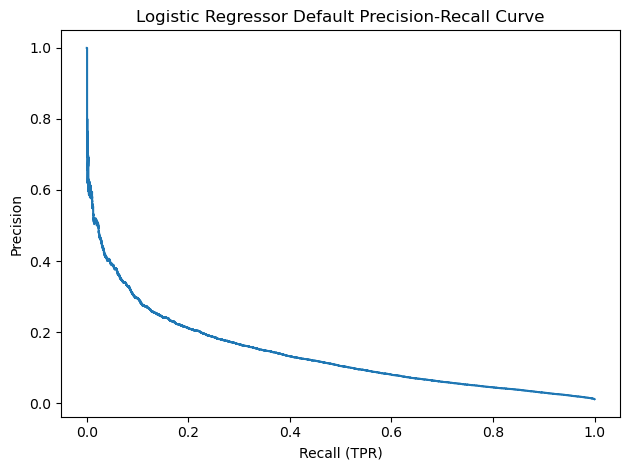

DecisionTree Default -- Optimal Threshold: 1.0000 | F1: 0.0726


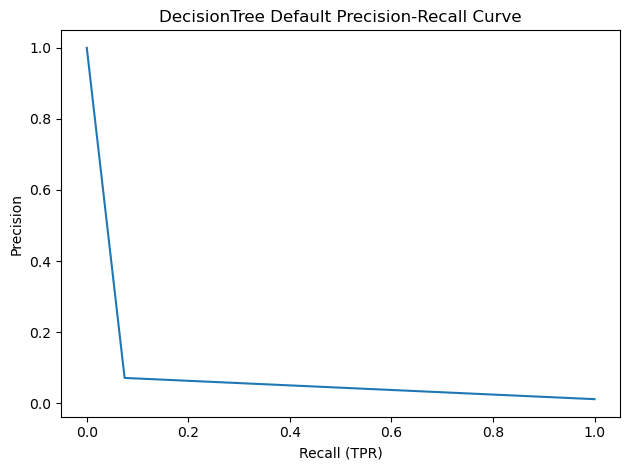

RandomForest Default -- Optimal Threshold: 0.0900 | F1: 0.1901


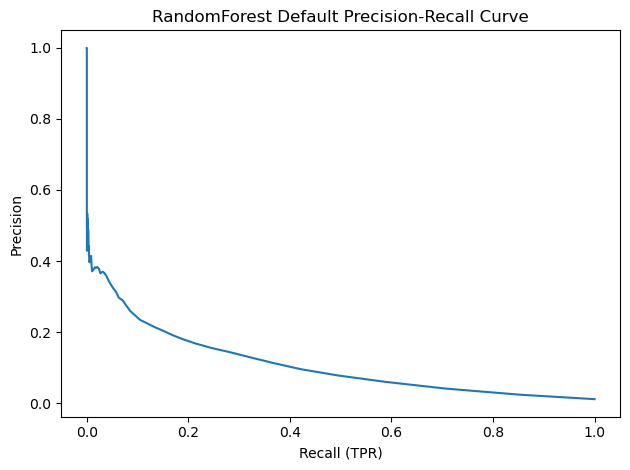

XGB Default -- Optimal Threshold: 0.9046 | F1: 0.2257


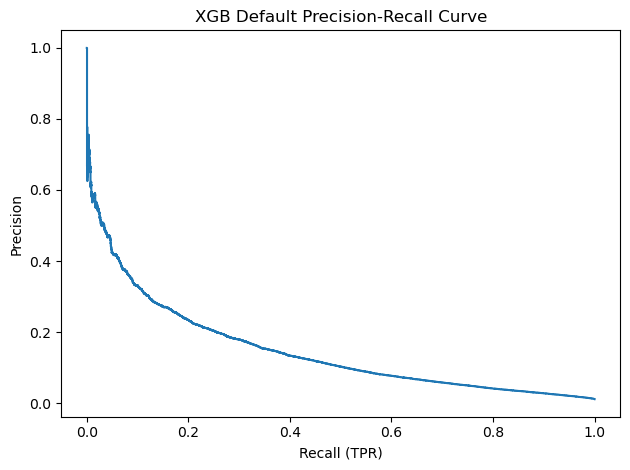

In [33]:
thresholds = [find_optimal_threshold(name, y_actual, model_probs) 
              for (name, y_actual, model_probs) in model_data]


lr_threshold, dt_threshold, rf_threshold, xgb_threshold = thresholds

### `Evaluating PRC plots` 

The precision-recall plots above provide visual context to the classification reports previously addressed. 

For the *logistic regression classifier*, an optimal threshold of 0.9175 was found with an f1-score of 0.2148. The plot shows considerable area under the curve, with the precision slope beginning to visibly decrease to level around a recall score of 0.025. The model maintains high confidence in fraud-detection, though precision truly drops around the peak of recall scores, modeling the paradoxical relationship between precision and recall.

With its curve dropping sharply and flattening near the baseline, the *DecisionTree* PRC plot reports an optimal threshold of 1.0 and an f1-score of 0.0726. This model is essentially useless, as the classifier only flags fraudulent applications when the threshold is set at the highest level. At this threshold, very few fraudulent applications, if any, would be detected. 

The *RandomForest* PRC reports an optimal threshold of 0.0900 and an f1-score of 0.1901. Though this plot's curve rises above the baseline, the threshold is so low that most of the dataset would be flagged as fraudulent, resulting in high class_1 recall with a significant proportion of false positives. 

*XGB's* precision-recall plot shows continuity in its curve, under which considerable area lies. Its optimal threshold lies just short of the logistic regressor's at 0.9046; however, its f1-score rises slightly above the logistic regression classifier's at 0.2257. Overall, this indicates XGB establishes a slightly better precision-recall tradeoff than the logistic regression classifier.

### `Application of Optimal Thresholds as Decision Boundary`

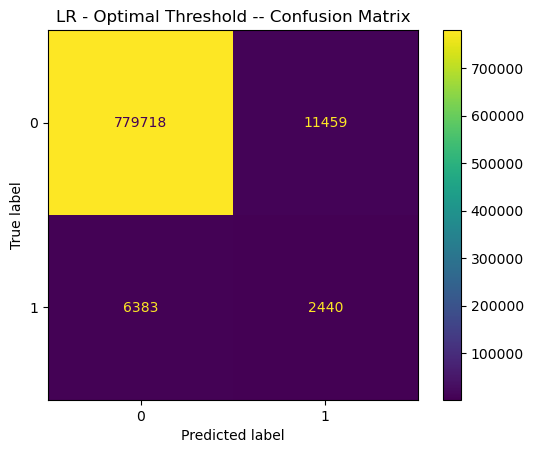

LR - Optimal Threshold -- Classification Report
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    791177
           1       0.18      0.28      0.21      8823

    accuracy                           0.98    800000
   macro avg       0.58      0.63      0.60    800000
weighted avg       0.98      0.98      0.98    800000

LR - Optimal Threshold -- ROC-AUC Score:  0.8831


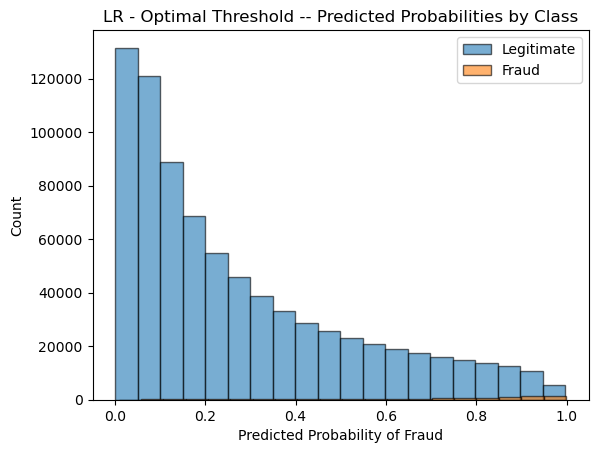

-----------------------


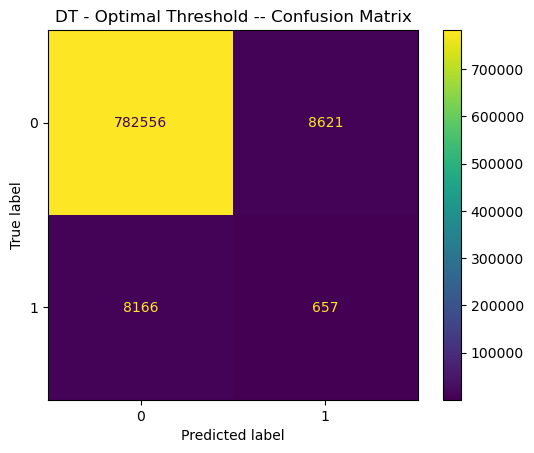

DT - Optimal Threshold -- Classification Report
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    791177
           1       0.07      0.07      0.07      8823

    accuracy                           0.98    800000
   macro avg       0.53      0.53      0.53    800000
weighted avg       0.98      0.98      0.98    800000

DT - Optimal Threshold -- ROC-AUC Score:  0.5318


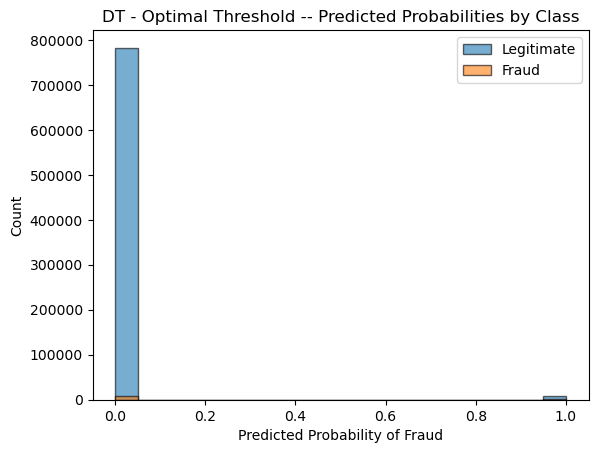

-----------------------


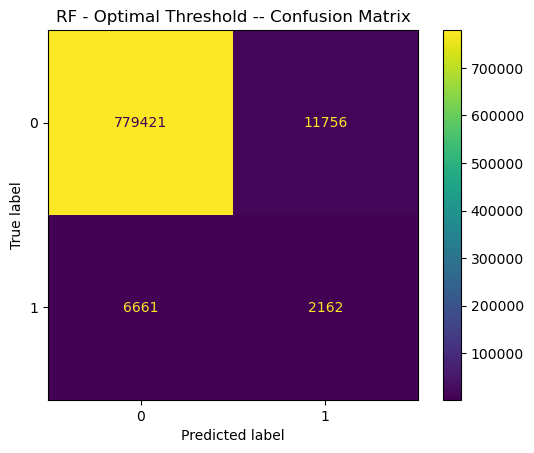

RF - Optimal Threshold -- Classification Report
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    791177
           1       0.16      0.25      0.19      8823

    accuracy                           0.98    800000
   macro avg       0.57      0.62      0.59    800000
weighted avg       0.98      0.98      0.98    800000

RF - Optimal Threshold -- ROC-AUC Score:  0.8199


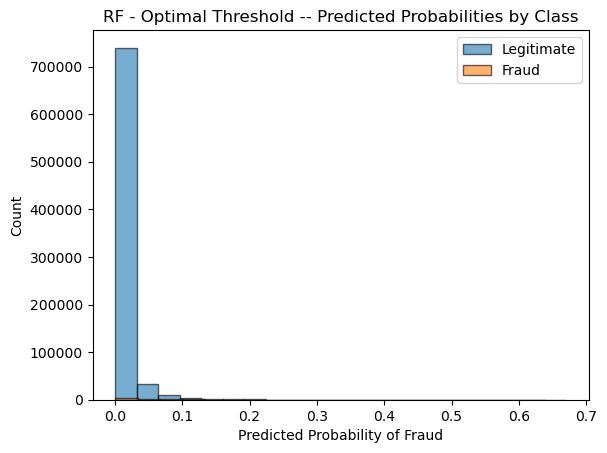

-----------------------


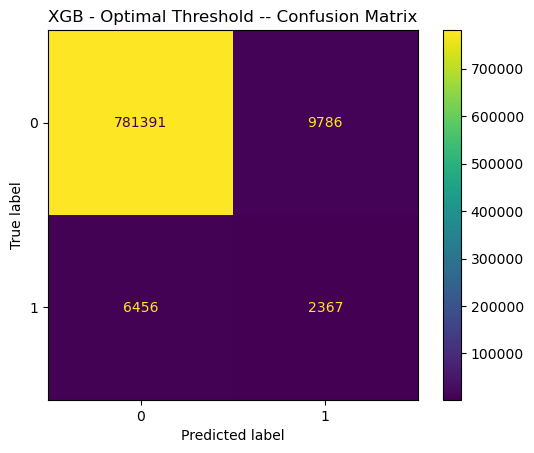

XGB - Optimal Threshold -- Classification Report
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    791177
           1       0.19      0.27      0.23      8823

    accuracy                           0.98    800000
   macro avg       0.59      0.63      0.61    800000
weighted avg       0.98      0.98      0.98    800000

XGB - Optimal Threshold -- ROC-AUC Score:  0.8775


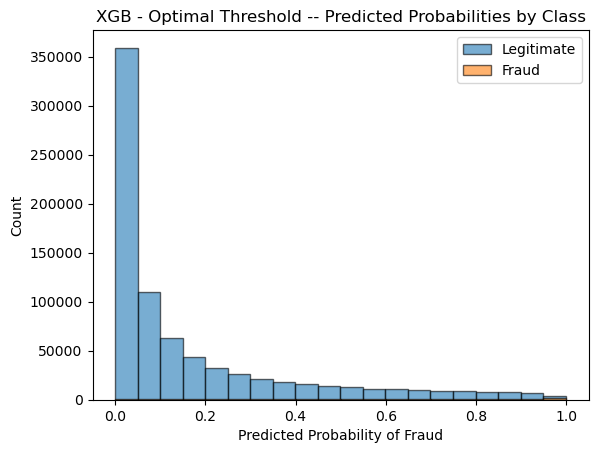

-----------------------


In [34]:
lr_preds_opt = (log_regressor_default_probs[:, 1] >= lr_threshold).astype(int)
dt_preds_opt = (decision_tree_default_probs[:, 1] >= dt_threshold).astype(int)
rf_preds_opt = (random_forest_default_probs[:, 1] >= rf_threshold).astype(int)
xgb_preds_opt = (xgboost_default_probs[:, 1]      >= xgb_threshold).astype(int)

evaluate_model('LR - Optimal Threshold', y_train, lr_preds_opt, log_regressor_default_probs)
evaluate_model('DT - Optimal Threshold', y_train, dt_preds_opt, decision_tree_default_probs)
evaluate_model('RF - Optimal Threshold', y_train, rf_preds_opt, random_forest_default_probs)
evaluate_model('XGB - Optimal Threshold', y_train, xgb_preds_opt, xgboost_default_probs)

### `Evaluation of Optimal Threshold Classification Reports`

Metrics :

---

LR = {


precision : {class_0 : 1.00, class_1 : 0.04}, 
recall:     {class_0 : 0.81, class_1 : 0.80}, 
f1-score :  {class_0 : 0.89, class_1 : 0.08}, 
ROC-AUC :   0.8831


} 

--

LR_opt_thresh = {

precision : {class_0 : 0.99, class_1 : 0.18}, 
recall:     {class_0 : 0.99, class_1 : 0.28}, 
f1-score :  {class_0 : 0.99, class_1 : 0.21}, 
ROC-AUC :   0.8831

} 

--

For the *logistic regression classifier*, application of the optimal threshold resulted in a slight drop in class_0 precision from (1.00 -> 0.99) and an increase in class_0 recall (0.81 -> 0.99). However, class_1 precision increased from 0.04 to 0.18 while class_1 recall dropped from 0.80 to 0.28. The f1-score rose across the board. Class_0 showed an increase from 0.89 to 0.99; class_1 showed an increase from 0.08 to 0.21. 

After identifying the optimal threshold, the logistic regressor classified 779,718 truly legitimate applicants and 2,440 truly fraudulent applicants. Of the actual legitimate applicants, 11,459 were wrongfully classified as fraudulent, with 6,383 of the actual fraudulent applicants being misclassified as legitimate. 

---

DT = {

precision: {class_0 : 0.99, class_1 : 0.07},
recall:    {class_0 : 0.99, class_1 : 0.07},
f1-score:  {class_0 : 0.99, class_1 : 0.07},
ROC-AUC:   0.5318

} 

--

DT_opt_thresh = {

precision: {class_0 : 0.99, class_1 : 0.07},
recall:    {class_0 : 0.99, class_1 : 0.07},
f1-score:  {class_0 : 0.99, class_1 : 0.07},
ROC-AUC:   0.5318

}

--

For the *DecisionTree*, identification of the optimal threshold resulted in no shift in classification metrics.

The DecisionTree's confusion matrix indicates that 782,556 truly legitimate applications were detected against 657 truly fraudulent applications. In between, 8,621 legitimate applicants were misclassified as fraudulent, with 8,166 fraudulent applicants being misclassified as legitimate.

---

RF = {

precision: {class_0 : 0.99, class_1 : 0.47},
recall:    {class_0 : 1.00, class_1 : 0.00},
f1-score:  {class_0 : 0.99, class_1 : 0.00},
ROC-AUC:   0.8199

}

--

RF_opt_thresh = {

precision: {class_0 : 0.99, class_1 : 0.16},
recall:    {class_0 : 0.99, class_1 : 0.25},
f1-score:  {class_0 : 0.99, class_1 : 0.19},
ROC-AUC:   0.8199

}

--

*RandomForest's* class_0 scores held steady for precision and f1 (0.99), with recall dropping slightly from 1.00 to 0.99. Class_1 showed a decrease in precision, from 0.47 to 0.16, and an increase for both recall (0.00 -> 0.25) and f1-score (0.00 -> 0.19). ROC-AUC scores held steady at 0.8199. 

The bagger's confusion matrix indicates that the model detected 779,421 truly legitimate applicants in contrast to 2,162 truly fraudulent applicants. Of the actual legitimate applicants, 11,756 were classified as fraudulent, though 6,661 of the actual fraudulent applicants slipped through the filter.

---

XGB = {

precision: {class_0 : 1.00, class_1 : 0.06},
recall:    {class_0 : 0.89, class_1 : 0.67},
f1-score:  {class_0 : 0.94, class_1 : 0.11},
ROC-AUC:    0.8775

} 

--

XGB_opt_thresh = {

precision: {class_0 : 0.99, class_1 : 0.19},
recall:    {class_0 : 0.99, class_1 : 0.27},
f1-score:  {class_0 : 0.99, class_1 : 0.23},
ROC-AUC:    0.8775

} 

--

*XGBoost's* class_0 precision score dropped slightly to 0.99, though its class_1 precision rose from 0.06 to 0.19. For recall, its class_0 score rose from 0.89 to 0.99, while class_1 dropped from 0.67 to 0.27. F1-score increased across the board; class_0 increased from 0.94 to 0.99, while class_1 increased from 0.11 to 0.23.

The booster's optimal threshold confusion matrix indicates segmentation of 781,391 truly legitimate applicants against 2,367 truly fraudulent applicants. 9,786 of the actual legitimate applicants received a bad rap and were placed into the fraudulent class, while 6,456 of the actual fraudsters slipped into the legitimate category.

---

Inspection of each model's histogram after identifying the optimal threshold reveals that the applicants' *predicted probabilities of fraud* show similar distributions to those observed prior to optimal threshold identification.  

# `Tuning Model Hyperparameters`

In [ ]:
%%time

log_regress_param_grid = {
    'penalty' : ['l1', 'l2'], # regularization methods
    'C' : np.logspace(-3, 3, 10), # regularization strengths
    'solver' : ['liblinear'] # solver that accommodates l1 and l2
}

decision_tree_param_grid = {
    'max_depth': [3, 5, 10, 20], # controlling depth to minimize overfitting
    'min_samples_leaf' : [1, 10, 50], # controlling for impurity
    'min_samples_split' : [2, 10, 50] # controlling for optimal split point
}

rf_param_grid = {
    'n_estimators' : [100, 200], # controlling quantity of estimators per iteration
    'max_depth' : [5, 10, 20, None], # strong estimators with more depth
    'max_features' : ['sqrt', 'log2'] # controlling for features upon which estimators split
}

xgb_param_grid = {
    'learning_rate' : [0.01, 0.1, 0.3], # small, controlled steps
    'max_depth' : [3, 6, 9], # shallow, weak estimators
    'n_estimators' : [100, 200] # controlling quantity of estimators per iteration
}

def tuning_model_hyperparameters(estimator, param_grid, x, y, label, **kwargs):
    '''Performs exhaustive GridSearches while identifying optimal hyperparameter settings and scores'''

    scoring = kwargs.get('scoring', 'roc_auc')
    n_jobs = kwargs.get('n_jobs', -1)
    cv = kwargs.get('cv', 5)
    verbose = kwargs.get('verbose', 1)

    grid_search_metrics = []

    grid_search = GridSearchCV(estimator=estimator,
                               param_grid=param_grid,
                               scoring=scoring,
                               n_jobs=n_jobs,
                               cv=cv,
                               verbose=verbose)
    
    grid_search.fit(X=x, y=y)

    best_params = grid_search.best_params_
    best_score = grid_search.best_score_
    best_estimator = grid_search.best_estimator_

    grid_search_metrics.append({
        'Algorithm' : label,
        'Optimal Params' : best_params,
        'Best estimator' : best_estimator,
        'Best Score' : best_score
    })

    grid_search_metrics_df = pd.DataFrame(grid_search_metrics)
    display(grid_search_metrics_df)

    return grid_search

CPU times: total: 0 ns
Wall time: 98.2 μs


## `Employ and Save Gridsearches for Tuned Models`

In [ ]:
%%time

lr_grid_search = tuning_model_hyperparameters(log_regressor_default, log_regress_param_grid, X_train_one_hot_enc, y_train, 'Logistic Regression Classifier Tuned')

joblib.dump(lr_grid_search, 'lr_grid_search.pkl')
print(f'LR grid search saved...')

In [ ]:
%%time

dt_grid_search = tuning_model_hyperparameters(decision_tree_default, decision_tree_param_grid, X_train_one_hot_enc, y_train, 'DecisionTree Tuned')

joblib.dump(dt_grid_search, 'dt_grid_search.pkl')
print(f'DT grid search saved...')

In [ ]:
%%time

rf_grid_search = tuning_model_hyperparameters(random_forest_default, rf_param_grid, X_train_one_hot_enc, y_train, 'RandomForest Tuned')

joblib.dump(rf_grid_search, 'rf_grid_search.pkl')
print(f'RF grid search saved...')

In [ ]:
%%time

xgb_grid_search = tuning_model_hyperparameters(xgboost_default, xgb_param_grid, X_train_one_hot_enc, y_train, 'XGBoost Tuned')

joblib.dump(xgb_grid_search, 'xgb_grid_search.pkl')
print(f'XGB grid search saved...')

## `Load Saved GridSearches for Tuned Models`

In [36]:
tuned_model_gridsearches = ['lr_grid_search.pkl', 'dt_grid_search.pkl', 'rf_grid_search.pkl', 'xgb_grid_search.pkl'] 

loaded_gridsearches = [joblib.load(gs) for gs in tuned_model_gridsearches]

lr_grid_search, dt_grid_search, rf_grid_search, xgb_grid_search = loaded_gridsearches

## `Model Selection`

### ROC-AUC Score Evaluation

Implementation of the GridSearchCV for each tuned model reveals the tuned XGB to be the strongest model, with hyperparameters tuned to an optimal '*learning_rate*' of 0.1, a '*max_depth*' of 3, '*n_estimators*' of 200, and an ROC-AUC score of ~89.6%. The DecisionTree performed the worst, despite its ROC-AUC score showing a substantial, positive shift after tuning.

### `Calculating Label and Probability Predictions per Tuned Classifier`

In [ ]:
tuned_model_list = [lr_grid_search.best_estimator_,
                    dt_grid_search.best_estimator_,
                    rf_grid_search.best_estimator_,
                    xgb_grid_search.best_estimator_]

logistic_regression_tuned_preds, logistic_regression_tuned_probs, \
decision_tree_tuned_preds, decision_tree_tuned_probs, \
random_forest_tuned_preds, random_forest_tuned_probs, \
xgb_tuned_preds, xgb_tuned_probs = calc_preds_and_probs(tuned_model_list, X=X_train_one_hot_enc, y=y_train, cv=5, method='predict_proba') 

### `Save Tuned Classifier Cross-Validation Results`

In [ ]:
cv_tuned_results = {
    'lr' : (logistic_regression_tuned_preds, logistic_regression_tuned_probs),
    'dt' : (decision_tree_tuned_preds, decision_tree_tuned_probs),
    'rf' : (random_forest_tuned_preds, random_forest_tuned_probs),
    'xgb' : (xgb_tuned_preds, xgb_tuned_probs)
}

joblib.dump(cv_tuned_results, 'cv_tuned_results.pkl')
print(f'Tuned CV results saved.')

### `Load Tuned Classifier Cross-Validation Results`

In [37]:
cv_tuned_results = joblib.load('cv_tuned_results.pkl')

logistic_regression_tuned_preds, logistic_regression_tuned_probs = cv_tuned_results['lr']
decision_tree_tuned_preds, decision_tree_tuned_probs = cv_tuned_results['dt']
random_forest_tuned_preds, random_forest_tuned_probs = cv_tuned_results['rf']
xgb_tuned_preds, xgb_tuned_probs = cv_tuned_results['xgb']

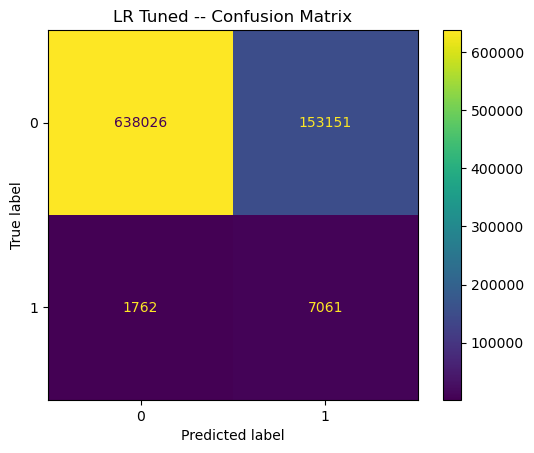

LR Tuned -- Classification Report
              precision    recall  f1-score   support

           0       1.00      0.81      0.89    791177
           1       0.04      0.80      0.08      8823

    accuracy                           0.81    800000
   macro avg       0.52      0.80      0.49    800000
weighted avg       0.99      0.81      0.88    800000

LR Tuned -- ROC-AUC Score:  0.8831


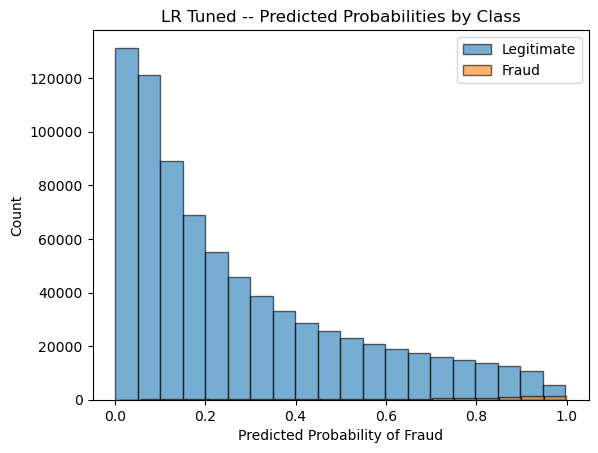

-----------------------


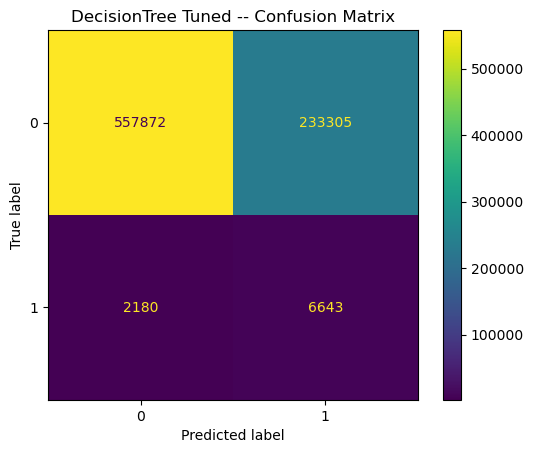

DecisionTree Tuned -- Classification Report
              precision    recall  f1-score   support

           0       1.00      0.71      0.83    791177
           1       0.03      0.75      0.05      8823

    accuracy                           0.71    800000
   macro avg       0.51      0.73      0.44    800000
weighted avg       0.99      0.71      0.82    800000

DecisionTree Tuned -- ROC-AUC Score:  0.8008


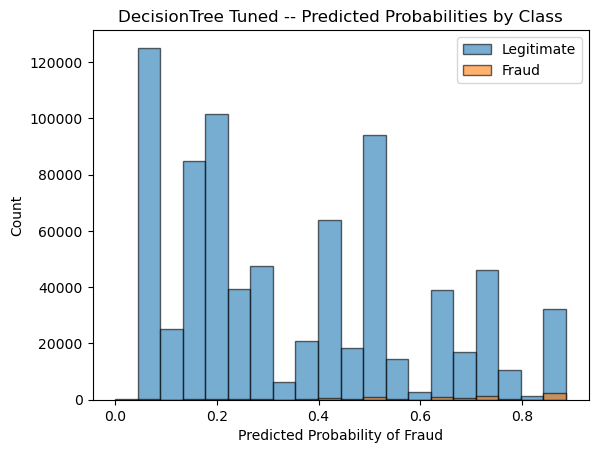

-----------------------


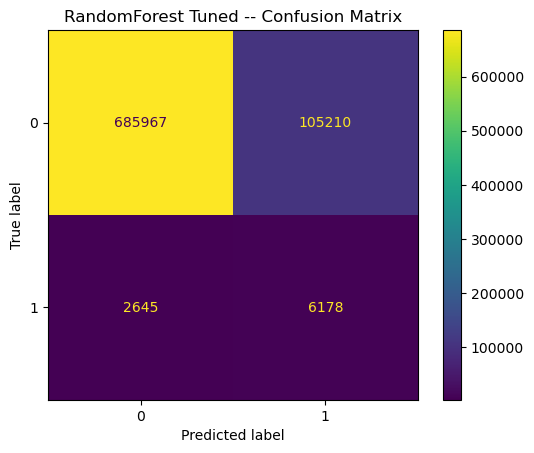

RandomForest Tuned -- Classification Report
              precision    recall  f1-score   support

           0       1.00      0.87      0.93    791177
           1       0.06      0.70      0.10      8823

    accuracy                           0.87    800000
   macro avg       0.53      0.78      0.51    800000
weighted avg       0.99      0.87      0.92    800000

RandomForest Tuned -- ROC-AUC Score:  0.8737


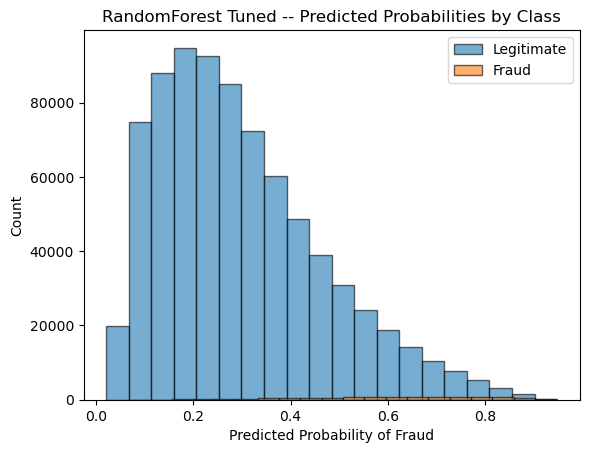

-----------------------


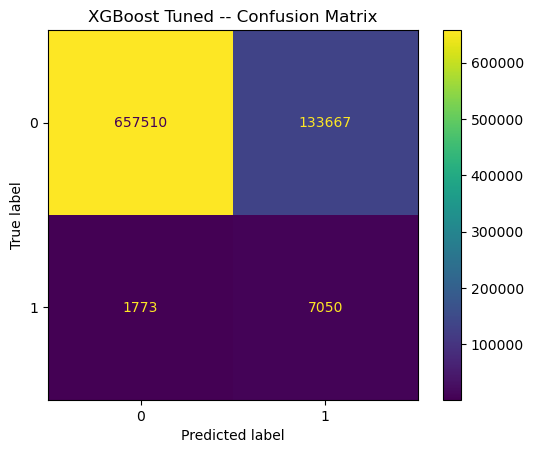

XGBoost Tuned -- Classification Report
              precision    recall  f1-score   support

           0       1.00      0.83      0.91    791177
           1       0.05      0.80      0.09      8823

    accuracy                           0.83    800000
   macro avg       0.52      0.82      0.50    800000
weighted avg       0.99      0.83      0.90    800000

XGBoost Tuned -- ROC-AUC Score:  0.8957


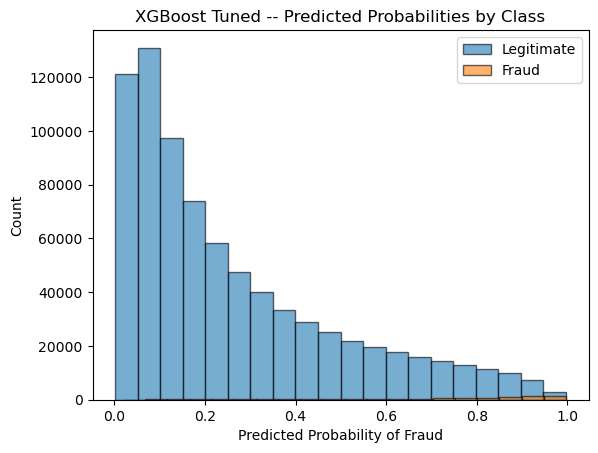

-----------------------


In [38]:
evaluate_model('LR Tuned', y_train, logistic_regression_tuned_preds, logistic_regression_tuned_probs)
evaluate_model('DecisionTree Tuned', y_train, decision_tree_tuned_preds, decision_tree_tuned_probs)
evaluate_model('RandomForest Tuned', y_train, random_forest_tuned_preds, random_forest_tuned_probs)
evaluate_model('XGBoost Tuned', y_train, xgb_tuned_preds, xgb_tuned_probs)

### `Classification Reports`

Metrics :

LR_Default = {

precision : {class_0 : 1.00, class_1 : 0.04}, 
recall:     {class_0 : 0.81, class_1 : 0.80}, 
f1-score :  {class_0 : 0.89, class_1 : 0.08}, 
ROC-AUC :   0.8831

} 

--

LR_Tuned = {

precision: {class_0 : 1.00, class_1 : 0.04},
recall:    {class_0 : 0.81, class_1 : 0.80},
f1-score:  {class_0 : 0.89, class_1 : 0.08},
ROC-AUC:   0.8831

} 



---


DT_Default = {

precision: {class_0 : 0.99, class_1 : 0.07},
recall:    {class_0 : 0.99, class_1 : 0.07},
f1-score:  {class_0 : 0.99, class_1 : 0.07},
ROC-AUC:   0.5318

} 

--

DT_Tuned = {

precision : {class_0 : 1.00, class_1 : 0.03}, 
recall:     {class_0 : 0.71, class_1 : 0.75}, 
f1-score :  {class_0 : 0.83, class_1 : 0.05}, 
ROC-AUC :   0.8008

} 

---

RF_Default = {

precision: {class_0 : 0.99, class_1 : 0.47},
recall:    {class_0 : 1.00, class_1 : 0.00},
f1-score:  {class_0 : 0.99, class_1 : 0.00},
ROC-AUC:   0.8199

}

--

RF_Tuned = {

precision: {class_0 : 1.00, class_1 : 0.06},
recall:    {class_0 : 0.87, class_1 : 0.70},
f1-score:  {class_0 : 0.93, class_1 : 0.10},
ROC-AUC:   0.8737

}

---

XGB_Default = {

precision: {class_0 : 1.00, class_1 : 0.06},
recall:    {class_0 : 0.89, class_1 : 0.67},
f1-score:  {class_0 : 0.94, class_1 : 0.11},
ROC-AUC:    0.8775

} 

--

XGB_Tuned = {

precision: {class_0 : 1.00, class_1 : 0.05},
recall:    {class_0 : 0.83, class_1 : 0.80},
f1-score:  {class_0 : 0.91, class_1 : 0.09},
ROC-AUC:    0.8957

} 

The metrics suggest that while tuning the logistic regressor produced no change in performance, each ensemble classifier showed an adjustment in its ROC-AUC score after tuning. Specifically, the DecisionTree's ROC-AUC score shifted from 0.5318 to 0.8008; the RandomForest's ROC-AUC score adjusted from 0.8199 to 0.8737; and XGBoost's ROC-AUC score repositioned from 0.8775 to 0.8957. 

Of the four models, the tuned RandomForest and XGBoost classifiers showed the highest precision and f1-scores, with RandomForest taking the lead for both class_0 and class_1 precision. However, the scores become more nuanced with regard to recall and ROC-AUC. When comparing the two ensemble models, the tuned RandomForest recalled 4% more of the class_0 applicants and 10% fewer of the class_1 applicants. This is likely related to the class imbalance of the dataset, among other factors. With a 1.1% fraud rate, the legitimate class contains much more data, and likely noise, from which the models can train. 

Using the *bagging* method, the tuned bagger (RandomForest) generates between 100-200 *strong* estimators per ensemble--as specified by the '*n_estimators*' hyperparameter--each with specified maximum-depth levels. Given that the RandomForest is designed to capitalize on the DecisionTree's tendency to overfit through generation of multiple estimators, specifying the '*max_depth*' permits control of growth, which ideally reduces the probability that each estimator within each ensemble will overfit. Additionally, some of the features are likely to carry different weights, so the '*max_features*' hyperparameter also controls how many random features each estimator accounts for when identifying the optimal split point. 

Under the hood, the booster (XGB) is designed to sequentially generate an aggregate of weak estimators which continually reduce the error of their predecessors. For this tuned booster model, '*learning_rate*' ensures smaller, controlled steps during Gradient Descent. If the flag lies at the bottom of the valley, application of small, controlled steps ensure that loss is minimized as opposed to potentially overstepping via larger, erratic steps. This XGBoost model is also tuned with the same '*n_estimators*' hyperparameter as the RandomForest, ensuring that each aggregate contains a healthy portion of trees to ensure continuity and stability of growth. However, the '*max_depth*' hyperparameter enables the estimators within this model to generate at shallower depths; this also minimizes the probability that the booster will overfit, promoting generalizability.

## `Evaluating Champion Model Performance on Test Set`

In [39]:
xgb_best = xgb_grid_search.best_estimator_

xgb_test_probs = xgb_best.predict_proba(X_test_ohe_enc)
xgb_test_preds = (xgb_test_probs[:, 1] >= 0.5).astype(int)

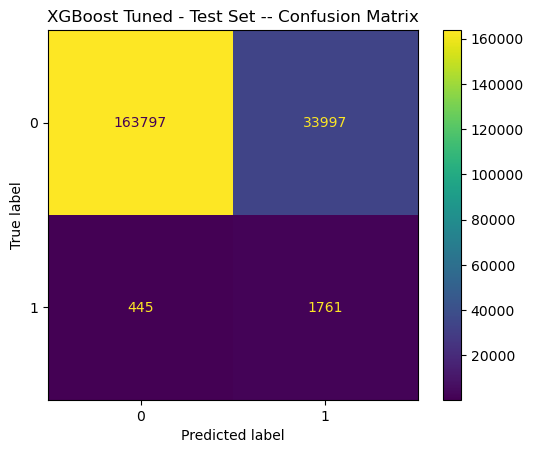

XGBoost Tuned - Test Set -- Classification Report
              precision    recall  f1-score   support

           0       1.00      0.83      0.90    197794
           1       0.05      0.80      0.09      2206

    accuracy                           0.83    200000
   macro avg       0.52      0.81      0.50    200000
weighted avg       0.99      0.83      0.90    200000

XGBoost Tuned - Test Set -- ROC-AUC Score:  0.8938


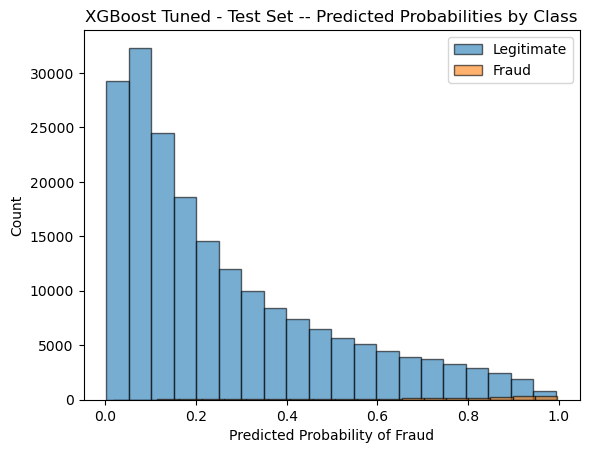

-----------------------


In [31]:
evaluate_model('XGBoost Tuned - Test Set', y_test, xgb_test_preds, xgb_test_probs)

After testing the champion model (*XGBoost*) on the test data (ROC-AUC = 0.8938) and comparing its performance to that of the cross-validation (0.8957), the model demonstrated negligible performance variance between the test and training data. In the *precision* category, the booster reported a class_0 score of 1.00, with a class_1 score of 0.05. As reflected in the *confusion matrix*, the model identified a significant portion of the truly legitimate applicants (*163,797* out of *200,000*) against 1,761 truly fraudulent applicants. By contrast, the model recalled 83% of the class_0 applicants while recalling 80% of the class_1 applicants. Unfortunately, 33,997 legitimate applicants were falsely detected as fraudulent while 445 fraudulent applicants slipped through the filter. In a real-world production setting, researchers would benefit from recalibrating the threshold and applying a cost-benefit framework to assess the balance between maintaining a particular false positive rate against recall metrics.

## `Evaluation of Feature Importance`

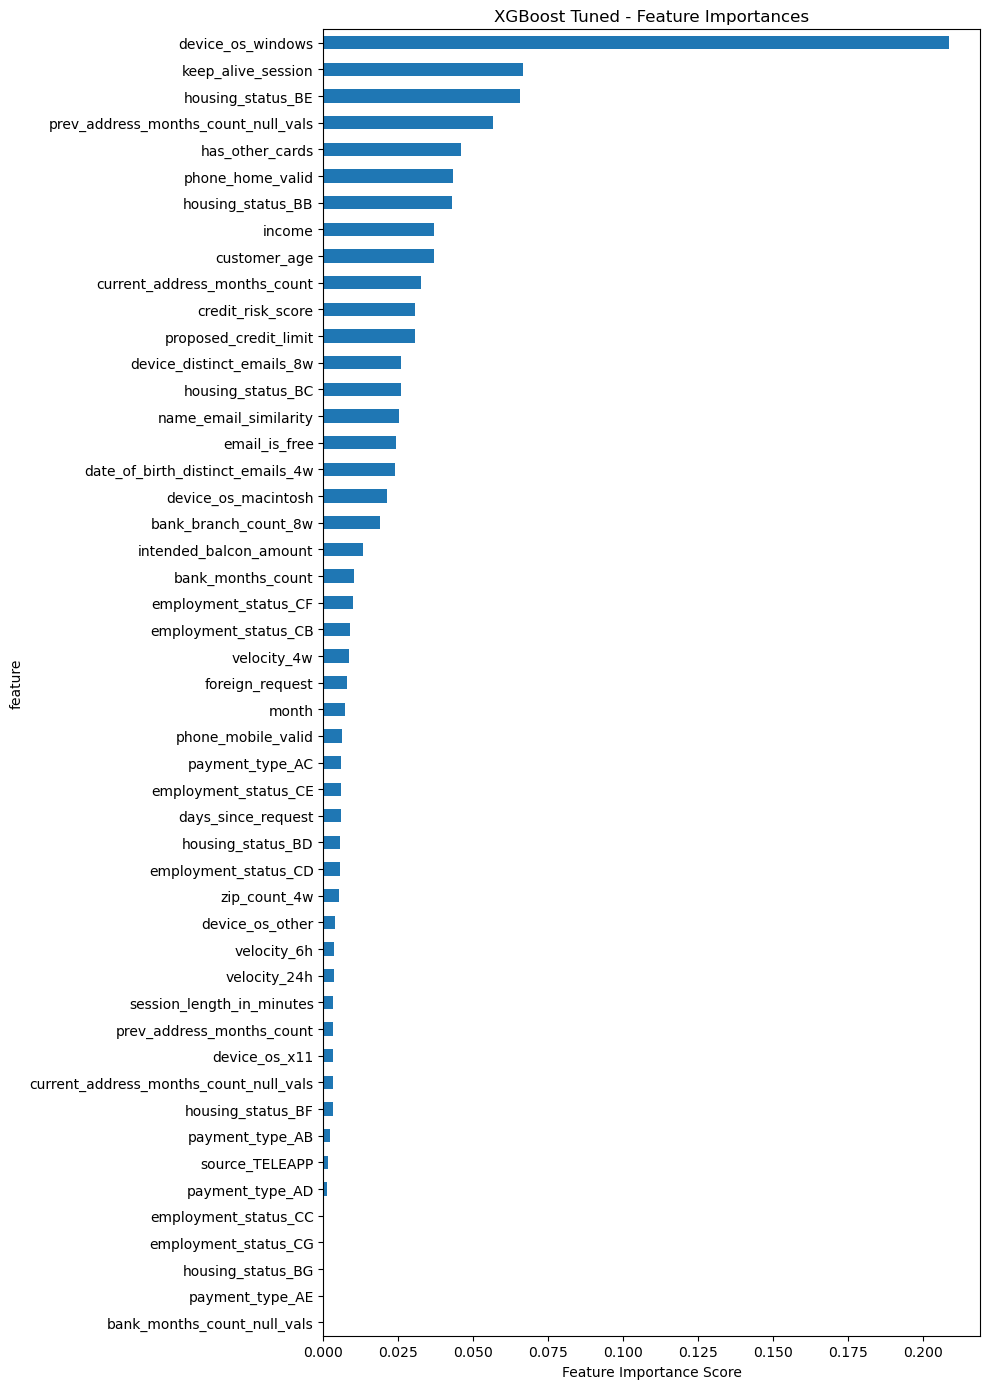

In [32]:
# plot
feature_names_clean = [n.split('__')[1] for n in ohe_transformer.get_feature_names_out()]

importance_df = pd.DataFrame({
    'feature' : feature_names_clean,
    'importance' : xgb_best.feature_importances_
}).sort_values('importance', ascending=False)

importance_df_clean = importance_df[importance_df['feature'] != 'device_fraud_count'].sort_values('importance', ascending=False)

importance_df_clean.plot(kind='barh', x='feature', y='importance', figsize=(10, 14), legend=False)
plt.title('XGBoost Tuned - Feature Importances')
plt.xlabel('Feature Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### `Feature Importance Summary`

Upon evaluating the Champion Model's feature importance, the feature analysis above paints a clear picture of each input feature's importance. Though 'device_os_windows' leads the pack by a wide margin, ~0.21, the remainder of the features show importance values of ~0.08 or lower. Additionally, 'keep_alive_session' and 'housing_status' are the only signal indicators aside from 'device_os_windows' to show importance scores above 0.075.

Despite certain indicators such as 'housing_status' having been anonymized, this is consistent when considering the cost-benefit analysis of optimizing for ROI in the perpetration of fraud via submission of bank account applications. Specifically, Macintosh devices are notoriously more costly to obtain while also being known to have tighter security, in comparison to Windows devices. Fraudsters are likely to deploy automated bots, which rely upon active sessions. Similar dependencies apply in the context of open-source intelligence techniques such as web-scraping. Additionally, fraudsters are likely to exhibit histories of higher transience, which can affect housing_status depending on how this metric is calculated. 

While the rest of the features fall at or below the 0.075 mark, 'employment_status_CC', 'employment_status_CG', 'housing_status_BG', 'payment_type_AE', and 'bank_months_count_null_vals' show values of 0.0, which indicates that these features serve as noise in the data.

# `Conclusion`

Overall, this study demonstrates the significance of starting with a simple foundation, scaling, and adjusting (i.e., tuning) with intention. The logistic regression classifier, being a simple, linear model, *is* that foundation. The DecisionTree, as one of the three non-linear models, carries its own strengths and limitations. While generally revered as a strong model, especially when working with data of higher cardinality, the DecisionTree clearly underperformed. However, to avoid confirmation bias, the ensemble models (*RandomForest* and *XGBoost*) were already selected for their contrasting functionality. 

As technology becomes more advanced, humans become increasingly more savvy and--cynical as it may be--conniving. Though applied in the context of financial fraud with a synthetic dataset, the foundation of research can be abstracted to other binary classification problems including both balanced and imbalanced real-world datasets. Additionally, researchers would undoubtedly benefit from curation of real-world data; however, appropriate measures must certainly be taken to protect sensitive information.